# LSTM

In [3]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=UserWarning)
tf.get_logger().setLevel("ERROR")

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [4]:
SEED          = 42
TEST_FRAC     = 0.20
WINDOW_SIZE   = 8
RNN_UNITS     = 40
DROPOUT       = 0.20
LEARNING_RATE = 1e-3
BATCH_SIZE    = 16
EPOCHS        = 200
PATIENCE      = 15
TARGET_COL    = 'Cortes'
FEATURE_COLS  = ['Cortes', 'Temp', 'Hum']

np.random.seed(SEED)
tf.random.set_seed(SEED)


In [7]:
# ── Carga de datos ───────────────────────────────────────────
df = pd.read_csv('completo.csv', parse_dates=['Semana'], index_col='Semana')
for col in ['Temp', 'Hum']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
df = df.asfreq('W-SUN').sort_index()

N       = len(df)
N_TRAIN = int(N * (1 - TEST_FRAC))
N_TEST  = N - N_TRAIN

train_df = df.iloc[:N_TRAIN]
test_df  = df.iloc[N_TRAIN:]
print(f"Train: {N_TRAIN} | Test: {N_TEST}")

Train: 209 | Test: 53


In [8]:
# ── Helpers ──────────────────────────────────────────────────
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

def build_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(RNN_UNITS, return_sequences=False),
        tf.keras.layers.Dropout(DROPOUT),
        tf.keras.layers.Dense(1),
    ])
    model.compile(
        loss='mse',
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        metrics=['mae'],
    )
    return model

def train_and_predict(X_train_s, y_train_s, X_test_s, y_test_real, n_features):
    """Entrena el modelo y predice recursivamente N_TEST pasos."""
    X_seq, y_seq = create_sequences(X_train_s, y_train_s, WINDOW_SIZE)

    model = build_model((WINDOW_SIZE, n_features))
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-6
        ),
    ]
    history = model.fit(
        X_seq, y_seq,
        validation_split = 0.15,
        epochs           = EPOCHS,
        batch_size       = BATCH_SIZE,
        callbacks        = callbacks,
        verbose          = 0,
    )
    print(f"    Épocas: {len(history.history['loss'])}")

    # Predicción recursiva
    window  = list(X_train_s[-WINDOW_SIZE:])
    preds_s = []
    for step in range(N_TEST):
        x_in   = np.array(window[-WINDOW_SIZE:]).reshape(1, WINDOW_SIZE, -1)
        pred_s = model.predict(x_in, verbose=0)[0, 0]
        preds_s.append(pred_s)
        if step < len(X_test_s):
            next_row    = X_test_s[step].copy()
            next_row[0] = pred_s
        else:
            next_row    = window[-1].copy()
            next_row[0] = pred_s
        window.append(next_row)

    return np.array(preds_s), history, model


# Almacén de resultados
lstm_results = []   # lista de dicts para exportar



## Univariado


▶ Cortes
    Épocas: 16
    RMSE=7.9298  MAE=5.7285

▶ Temp
    Épocas: 32
    RMSE=5.7406  MAE=4.6899

▶ Hum
    Épocas: 60
    RMSE=12.5247  MAE=11.0524


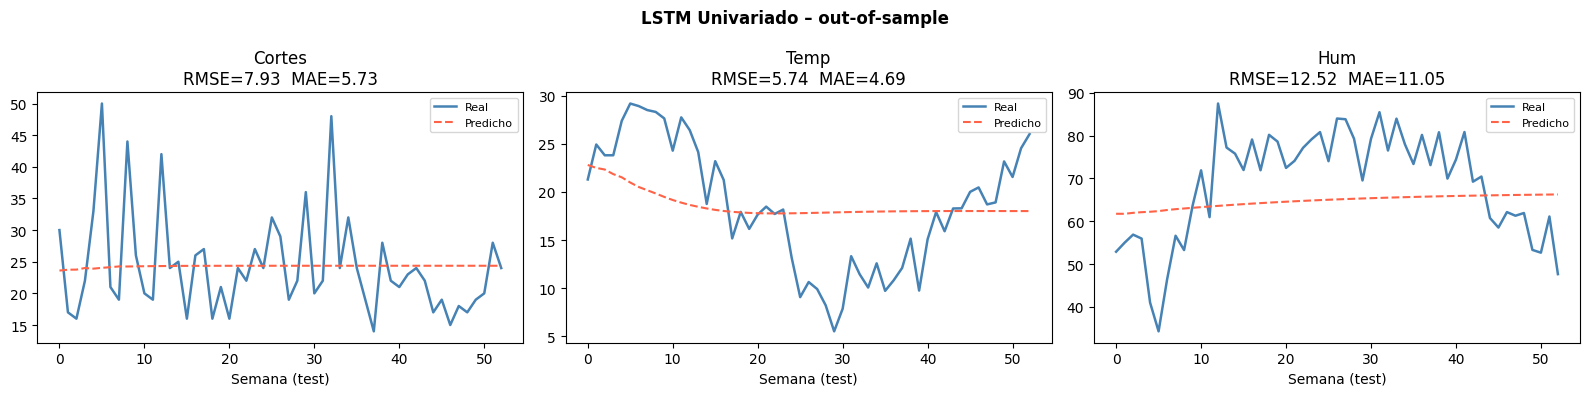

In [9]:
SERIES_UNI = {
    'Cortes': df['Cortes'].values.astype(float),
    'Temp'  : df['Temp'].values.astype(float),
    'Hum'   : df['Hum'].values.astype(float),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('LSTM Univariado – out-of-sample', fontweight='bold')

for ax, (serie, arr) in zip(axes, SERIES_UNI.items()):
    print(f"\n▶ {serie}")

    y_train_arr = arr[:N_TRAIN]
    y_test_arr  = arr[N_TRAIN:]

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_s = scaler_X.fit_transform(y_train_arr.reshape(-1, 1))
    y_train_s = scaler_y.fit_transform(y_train_arr.reshape(-1, 1)).ravel()
    X_test_s  = scaler_X.transform(y_test_arr.reshape(-1, 1))

    preds_s, history, _ = train_and_predict(
        X_train_s, y_train_s, X_test_s, y_test_arr, n_features=1
    )
    y_pred = scaler_y.inverse_transform(preds_s.reshape(-1, 1)).ravel()

    rmse_val = float(np.sqrt(mean_squared_error(y_test_arr, y_pred)))
    mae_val  = float(mean_absolute_error(y_test_arr, y_pred))
    print(f"    RMSE={rmse_val:.4f}  MAE={mae_val:.4f}")

    lstm_results.append({
        'model': 'LSTM_Uni', 'serie': serie,
        'date' : test_df.index,
        'y_true': y_test_arr, 'y_pred': y_pred,
        'rmse': round(rmse_val, 4), 'mae': round(mae_val, 4),
    })

    ax.plot(y_test_arr, label='Real',     color='steelblue', lw=1.8)
    ax.plot(y_pred,     label='Predicho', color='tomato',    lw=1.5, linestyle='--')
    ax.set_title(f'{serie}\nRMSE={rmse_val:.2f}  MAE={mae_val:.2f}')
    ax.set_xlabel('Semana (test)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('lstm_univariado.png', dpi=120, bbox_inches='tight')
plt.show()


# Multivariado

    Épocas: 28
  RMSE=8.1367  MAE=6.1649


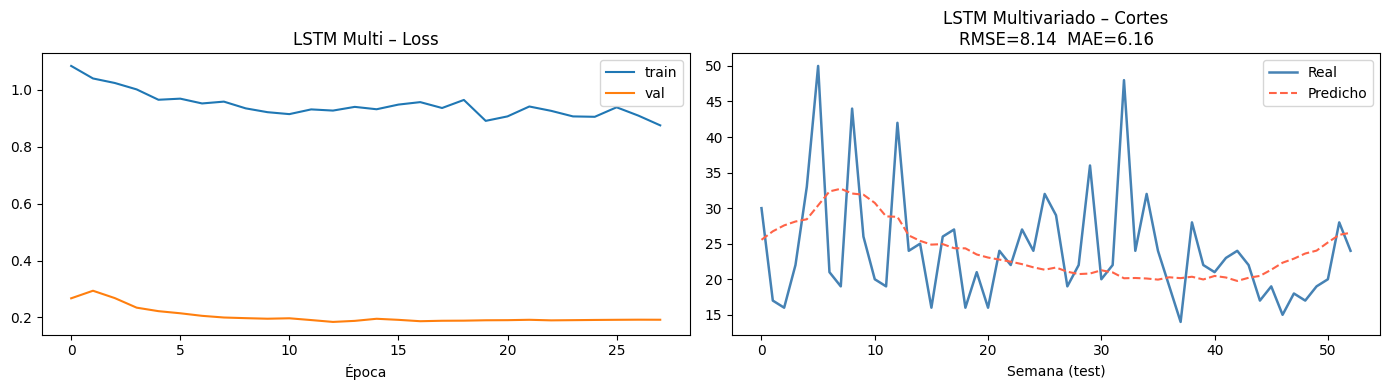

In [10]:
FEATURE_COLS = ['Cortes', 'Temp', 'Hum']

X_train_raw = train_df[FEATURE_COLS].values
y_train_raw = train_df['Cortes'].values.astype(float)
X_test_raw  = test_df[FEATURE_COLS].values
y_test_raw  = test_df['Cortes'].values.astype(float)

scaler_Xm = StandardScaler()
scaler_ym = StandardScaler()

X_train_ms = scaler_Xm.fit_transform(X_train_raw)
y_train_ms = scaler_ym.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
X_test_ms  = scaler_Xm.transform(X_test_raw)

preds_ms, history_m, _ = train_and_predict(
    X_train_ms, y_train_ms, X_test_ms, y_test_raw, n_features=3
)
y_pred_m = scaler_ym.inverse_transform(preds_ms.reshape(-1, 1)).ravel()

rmse_m = float(np.sqrt(mean_squared_error(y_test_raw, y_pred_m)))
mae_m  = float(mean_absolute_error(y_test_raw, y_pred_m))
print(f"  RMSE={rmse_m:.4f}  MAE={mae_m:.4f}")

lstm_results.append({
    'model': 'LSTM_Multi', 'serie': 'Cortes (Temp+Hum)',
    'date' : test_df.index,
    'y_true': y_test_raw, 'y_pred': y_pred_m,
    'rmse': round(rmse_m, 4), 'mae': round(mae_m, 4),
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_m.history['loss'],     label='train')
axes[0].plot(history_m.history['val_loss'], label='val')
axes[0].set_title('LSTM Multi – Loss')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(y_test_raw, label='Real',     color='steelblue', lw=1.8)
axes[1].plot(y_pred_m,   label='Predicho', color='tomato',    lw=1.5, linestyle='--')
axes[1].set_title(f'LSTM Multivariado – Cortes\nRMSE={rmse_m:.2f}  MAE={mae_m:.2f}')
axes[1].set_xlabel('Semana (test)')
axes[1].legend()
plt.tight_layout()
plt.savefig('lstm_multivariado.png', dpi=120, bbox_inches='tight')
plt.show()



# Exportar Resultados

In [11]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/SDT/Resultados"
os.makedirs(BASE_PATH, exist_ok=True)

Mounted at /content/drive


In [12]:
all_preds   = []
all_metrics = []

for r in lstm_results:
    df_pred = pd.DataFrame({
        'model' : r['model'],
        'serie' : r['serie'],
        'date'  : r['date'],
        'y_true': r['y_true'],
        'y_pred': r['y_pred'],
    })
    all_preds.append(df_pred)
    all_metrics.append({
        'model': r['model'],
        'serie': r['serie'],
        'rmse' : r['rmse'],
        'mae'  : r['mae'],
    })

pd.concat(all_preds).to_csv(
    f"{BASE_PATH}/predictions_LSTM.csv", index=False)
pd.DataFrame(all_metrics).to_csv(
    f"{BASE_PATH}/metrics_LSTM.csv", index=False)

print("\n✔ LSTM guardado correctamente")
print(pd.DataFrame(all_metrics))


✔ LSTM guardado correctamente
        model              serie     rmse      mae
0    LSTM_Uni             Cortes   7.9298   5.7285
1    LSTM_Uni               Temp   5.7406   4.6899
2    LSTM_Uni                Hum  12.5247  11.0524
3  LSTM_Multi  Cortes (Temp+Hum)   8.1367   6.1649
